In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gmean
import os
import re
import glob

from qiskit_optimization.converters import QuadraticProgramToQubo
import sys
from qiskit.circuit.library import QAOAAnsatz

sys.path.append("../")
from testing_scripts.qaoa_utils import QAOASolver
import testing_scripts.graphs_utils as graph_utils
from testing_scripts.knapsack_utils import generate_knapsack_instance 


import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
SMALL_SIZE = 11
MEDIUM_SIZE = 12.5
BIGGER_SIZE = 15

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

plt.rcParams["figure.figsize"] = (8, 6)   # width, height in inches


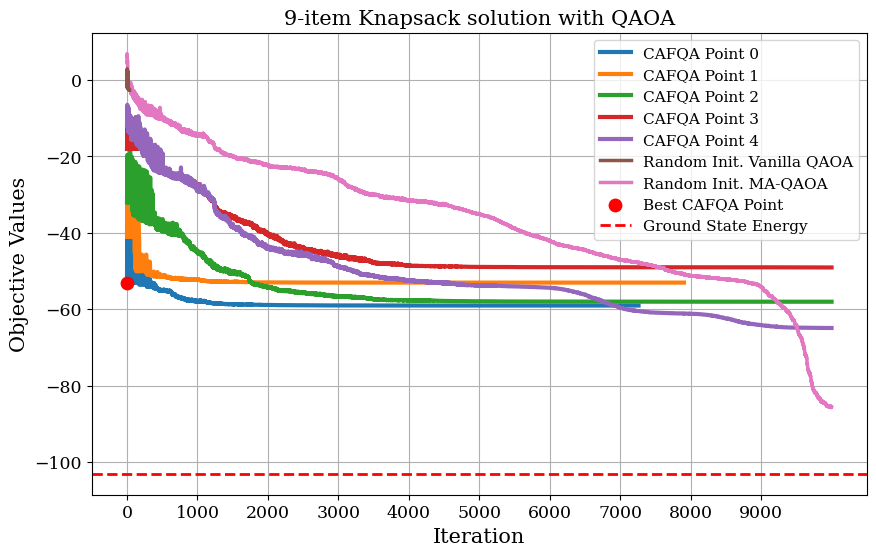

In [3]:
#Approx Ratio
cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/12_qbs/result_2.npy', allow_pickle=True).item()

# Dynamically find all 'task_' keys in Task_results
tasks = [key for key in cafqa_diff_points_data['Task_results'] if key.startswith('task_')]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}
exact_energy = cafqa_diff_points_data['Exact_Ground_State_Energy']
# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point {i}', linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', linewidth=2.5,zorder=10)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA', linewidth=2.5)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']
# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.scatter(0, obj_values['task_0'][0], color='red', s=80, zorder=5, label='Best CAFQA Point')
plt.axhline(y=exact_energy, color='red', linestyle='--', linewidth=2, label='Ground State Energy')
plt.legend()
plt.grid()
plt.title('9-item Knapsack solution with QAOA')
plt.xticks(ticks=np.arange(0, 10000, 1000))
# plt.savefig('../plots/knapsack_qaoa_9_item.png', dpi=500, bbox_inches='tight')
plt.show()

In [4]:
cafqa_diff_points_data['Task_results']['task_0']

{'task_name': 'task_0',
 'result':  message: Optimization terminated successfully.
  success: True
   status: 1
      fun: -58.99986787801112
        x: [ 1.573e+00  3.092e+00 ...  3.142e+00  4.712e+00]
     nfev: 7261
    maxcv: 0.0,
 'fitness_val': np.float64(-53.0),
 'obj_values': [array(-53.),
  array(-48.40302306),
  array(-53.),
  array(-41.04785995),
  array(-41.04785995),
  array(-45.1851392),
  array(-45.1851392),
  array(-40.58816226),
  array(-48.86272075),
  array(-49.32241845),
  array(-53.),
  array(-44.26574381),
  array(-47.95117409),
  array(-49.32241845),
  array(-41.04785995),
  array(-32.77330146),
  array(-36.45088301),
  array(-45.1851392),
  array(-44.72544151),
  array(-45.1851392),
  array(-37.3702784),
  array(-45.1851392),
  array(-44.72544151),
  array(-36.45088301),
  array(-49.32241845),
  array(-48.40302306),
  array(-53.),
  array(-49.32241845),
  array(-48.86272075),
  array(-53.),
  array(-45.1851392),
  array(-49.32241845),
  array(-41.50755765),
  ar

In [5]:
def compute_relative_errors(task_num, idx):
    cafqa_val = cafqa_diff_points_data['Task_results'][f'task_{task_num}']['obj_values'][idx]
    random_val = cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'][idx]
    cafqa_err = np.abs((cafqa_val - exact_energy) / exact_energy)
    random_err = np.abs((random_val - exact_energy) / exact_energy)
    print(f"CAFQA relative error: {np.round(cafqa_err, 3)}")
    print(f"Random MA-QAOA relative error: {np.round(random_err, 3)}")
    return np.round(cafqa_err, 3), np.round(random_err, 3)

# Example usage:
compute_relative_errors(1,40)

CAFQA relative error: 0.602
Random MA-QAOA relative error: 0.975


(np.float64(0.602), np.float64(0.975))

In [6]:
k_reg_cafqa_rel_err_12 = [0.137,0.106,0.259,0.155,0.167,0.268,0.039,0.09,0.228,0.15]
k_reg_random_rel_err_12 = [0.167,0.125,0.291,0.149,0.225,0.207,0.162,0.175,0.172,0.204]

In [7]:
kp_cafqa_rel_err_4 = [0.017, 0.101, 0.04, 0.021 , 0.018, 0.031, 0.019, 0.012, 0.005, 0.007]
kp_random_rel_err_4 = [0.728, 0.858, 0.722, 0.246, 0.64, 0.537, 0.605, 0.682, 0.63, 0.63 ]

kp_cafqa_rel_err_9 = [0.134, 0.053, 0.045, 0.021, 0.057, 0.218,0.068, 0.221,0.012,0.032 ]
kp_random_rel_err_9 = [0.247, 0.901, 0.397, 0.302, 0.46, 0.121,0.097, 0.408,0.142, 0.159]

kp_cafqa_rel_err_12 = [0.236,0.309,0.197, 0.309,0.347,0.696, 0.373,0.443,0.496,0.395 ]
kp_random_rel_err_12 = [0.309,0.495,0.695, 0.326,0.42,0.975, 0.389,0.558, 0.395,0.676]

In [8]:
complete_graph_cafqa_rel_err_8 = [0.003, 0.007, 0.053, 0.004, 0.032, 0.006, 0.001, 0.042, 0.143 , 0.002]
complete_graph_random_rel_err_8 = [0.507, 0.054, 0.004, 0.026, 0.002, 0.089, 0.734, 0.003, 0.244, 0.133]

complete_graph_cafqa_rel_err_12 = [0.148,0.37, 0.228,0.122, 0.037,0.339, 0.039, 0.149, 0.001, 0.279]
complete_graph_random_rel_err_12 = [0.09, 0.169, 0.069, 0.648, 0.445,0.771, 0.402, 0.106, 0.196, 0.225]

complete_graph_cafqa_rel_err_16 = [0.583, 0.627, 0.525, 0.575, 0.527, 0.588, 0.528, 0.339, 0.617, 0.602]
complete_graph_random_rel_err_16 = [0.632, 0.579, 0.602, 0.752, 0.618, 0.75, 0.656, 0.564, 0.756, 0.9 ]

In [9]:
# def print_mean_and_std(arr1, arr2, label1="cafqa", label2="random"):
#     mean1 = np.mean(arr1)
#     std1 = np.std(arr1)
#     mean2 = np.mean(arr2)
#     std2 = np.std(arr2)
#     print(f"{label1}: mean={mean1:.3f}, std={std1:.3f}")
#     print(f"{label2}: mean={mean2:.3f}, std={std2:.3f}")

def print_gmean_and_std(arr1, arr2, label1="cafqa", label2="random"):
    gmean1 = gmean(arr1)
    std1 = np.std(arr1)
    gmean2 = gmean(arr2)
    std2 = np.std(arr2)
    print(f"{label1}: gmean={gmean1:.3f}, std={std1:.3f}")
    print(f"{label2}: gmean={gmean2:.3f}, std={std2:.3f}")

print_gmean_and_std(k_reg_cafqa_rel_err_12,k_reg_random_rel_err_12)

cafqa: gmean=0.141, std=0.070
random: gmean=0.183, std=0.044


In [10]:
cafqa_diff_points_data['Task_results'].keys()

dict_keys(['task_0', 'task_1', 'task_2', 'task_3', 'task_4', 'Random_MA-QAOA', 'Vanilla_task'])

In [11]:
cafqa_diff_points_data['Task_results']['Vanilla_task']['approx_ratio'],cafqa_diff_points_data['Task_results']['task_1']['approx_ratio']

(0.8022920948616601, 0.9009754940711461)

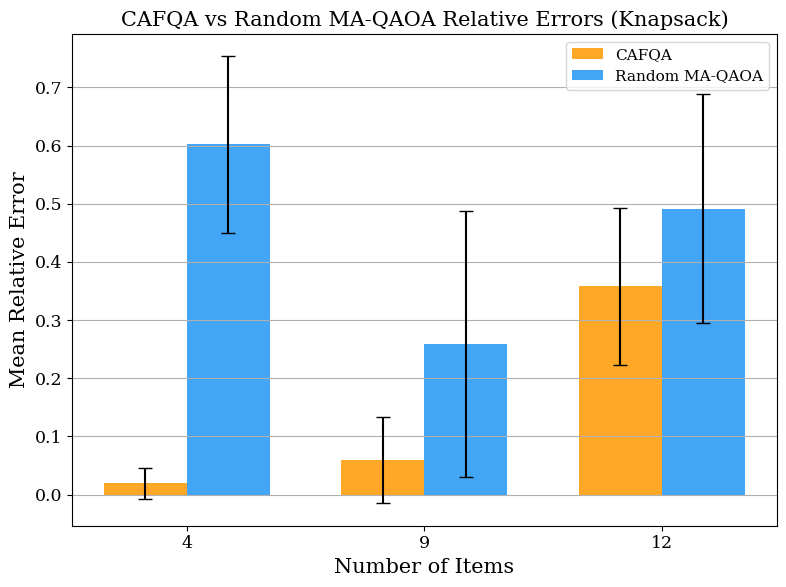

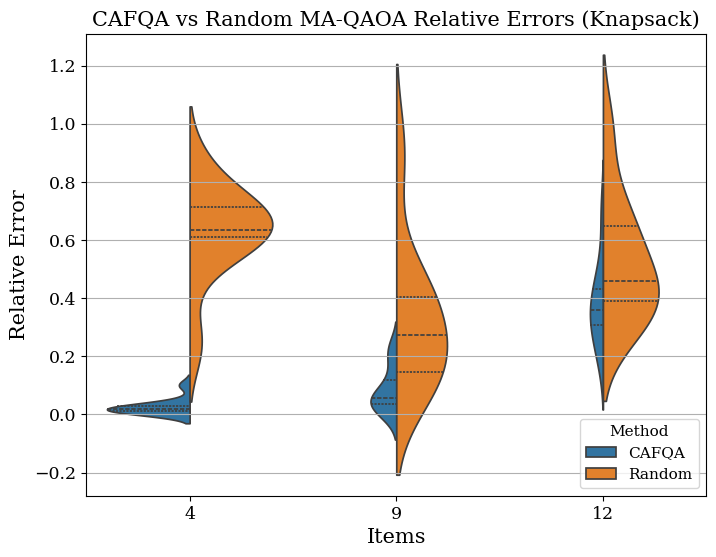

In [12]:
# Calculate means and standard deviations for each group
methods = ['CAFQA', 'CAFQA', 'CAFQA', 'Random', 'Random', 'Random']
item_sizes = [4, 9, 12, 4, 9, 12]
data = [
    gmean(kp_cafqa_rel_err_4),
    gmean(kp_cafqa_rel_err_9),
    gmean(kp_cafqa_rel_err_12),
    gmean(kp_random_rel_err_4),
    gmean(kp_random_rel_err_9),
    gmean(kp_random_rel_err_12)
]
stds = [
    np.std(kp_cafqa_rel_err_4),
    np.std(kp_cafqa_rel_err_9),
    np.std(kp_cafqa_rel_err_12),
    np.std(kp_random_rel_err_4),
    np.std(kp_random_rel_err_9),
    np.std(kp_random_rel_err_12)
]

# Set up bar positions so that CAFQA and Random for each item size are grouped together
n_groups = 3  # 4, 9, 12 items
bar_width = 0.35
index = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(8, 6))

# CAFQA bars (left in each group)
ax.bar(index - bar_width/2, data[:3], bar_width, yerr=stds[:3], label='CAFQA', color='#FFA726', capsize=5)
# Random bars (right in each group)
ax.bar(index + bar_width/2, data[3:], bar_width, yerr=stds[3:], label='Random MA-QAOA', color='#42A5F5', capsize=5)

# Set x-ticks and labels
ax.set_xticks(index)
ax.set_xticklabels(['4', '9', '12'])
ax.set_xlabel('Number of Items')
ax.set_ylabel('Mean Relative Error')
ax.set_title('CAFQA vs Random MA-QAOA Relative Errors (Knapsack)')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# Prepare data for boxplot with grouped categories for CAFQA and Random
data = [
    kp_cafqa_rel_err_4,
    kp_cafqa_rel_err_9,
    kp_cafqa_rel_err_12,
    kp_random_rel_err_4,
    kp_random_rel_err_9,
    kp_random_rel_err_12
]
labels = [
    "CAFQA 4", "CAFQA 9", "CAFQA 12",
    "Random 4", "Random 9", "Random 12"
]

# Assign group and item size for each box
group = ['CAFQA'] * 3 + ['Random'] * 3
item_size = [4, 9, 12] * 2

# Flatten data for DataFrame
flat_data = []
flat_group = []
flat_item_size = []
for d, g, n in zip(data, group, item_size):
    flat_data.extend(d)
    flat_group.extend([g] * len(d))
    flat_item_size.extend([n] * len(d))

df_box = pd.DataFrame({
    'Relative Error': flat_data,
    'Method': flat_group,
    'Items': flat_item_size
})

plt.figure(figsize=(8, 6))
sns.violinplot(data=df_box, x='Items', y='Relative Error', hue='Method', split=True, inner='quartile')
plt.title("CAFQA vs Random MA-QAOA Relative Errors (Knapsack)")
plt.grid(axis='y')
plt.show()

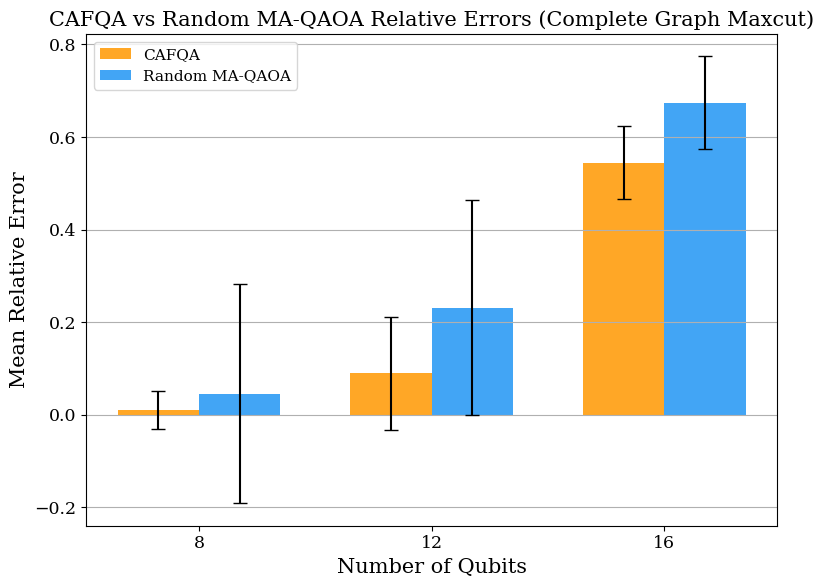

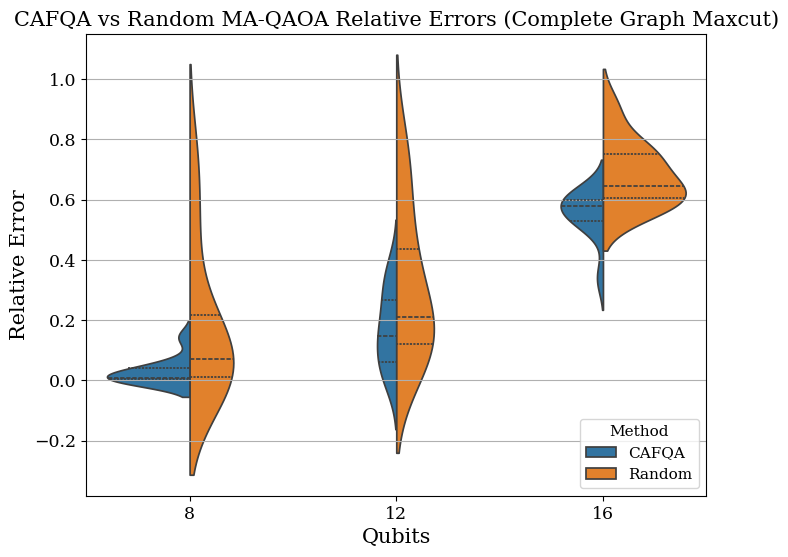

In [13]:
# Calculate means and standard deviations for each group
methods = ['CAFQA', 'CAFQA', 'CAFQA', 'Random', 'Random', 'Random']
item_sizes = [8, 12, 16, 8, 12, 16]
data = [
    gmean(complete_graph_cafqa_rel_err_8),
    gmean(complete_graph_cafqa_rel_err_12),
    gmean(complete_graph_cafqa_rel_err_16),
    gmean(complete_graph_random_rel_err_8),
    gmean(complete_graph_random_rel_err_12),
    gmean(complete_graph_random_rel_err_16)
]
stds = [
    np.std(complete_graph_cafqa_rel_err_8),
    np.std(complete_graph_cafqa_rel_err_12),
    np.std(complete_graph_cafqa_rel_err_16),
    np.std(complete_graph_random_rel_err_8),
    np.std(complete_graph_random_rel_err_12),
    np.std(complete_graph_random_rel_err_16)
]

# Set up bar positions so that CAFQA and Random for each item size are grouped together
n_groups = 3  # 8, 12, 16 qubits
bar_width = 0.35
index = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(8, 6))

# CAFQA bars (left in each group)
ax.bar(index - bar_width/2, data[:3], bar_width, yerr=stds[:3], label='CAFQA', color='#FFA726', capsize=5)
# Random bars (right in each group)
ax.bar(index + bar_width/2, data[3:], bar_width, yerr=stds[3:], label='Random MA-QAOA', color='#42A5F5', capsize=5)

# Set x-ticks and labels
ax.set_xticks(index)
ax.set_xticklabels(['8', '12', '16'])
ax.set_xlabel('Number of Qubits')
ax.set_ylabel('Mean Relative Error')
ax.set_title('CAFQA vs Random MA-QAOA Relative Errors (Complete Graph Maxcut)')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# Prepare data for boxplot with grouped categories for CAFQA and Random
data = [
    complete_graph_cafqa_rel_err_8,
    complete_graph_cafqa_rel_err_12,
    complete_graph_cafqa_rel_err_16,
    complete_graph_random_rel_err_8,
    complete_graph_random_rel_err_12,
    complete_graph_random_rel_err_16
]
labels = [
    "CAFQA 8", "CAFQA 12", "CAFQA 16",
    "Random 8", "Random 12", "Random 16"
]

# Assign group and item size for each box
group = ['CAFQA'] * 3 + ['Random'] * 3
item_size = [8, 12, 16] * 2

# Flatten data for DataFrame
flat_data = []
flat_group = []
flat_item_size = []
for d, g, n in zip(data, group, item_size):
    flat_data.extend(d)
    flat_group.extend([g] * len(d))
    flat_item_size.extend([n] * len(d))

df_box = pd.DataFrame({
    'Relative Error': flat_data,
    'Method': flat_group,
    'Qubits': flat_item_size
})

plt.figure(figsize=(8, 6))
sns.violinplot(data=df_box, x='Qubits', y='Relative Error', hue='Method', split=True, inner='quartile')
plt.title("CAFQA vs Random MA-QAOA Relative Errors (Complete Graph Maxcut)")
plt.grid(axis='y')
plt.show()

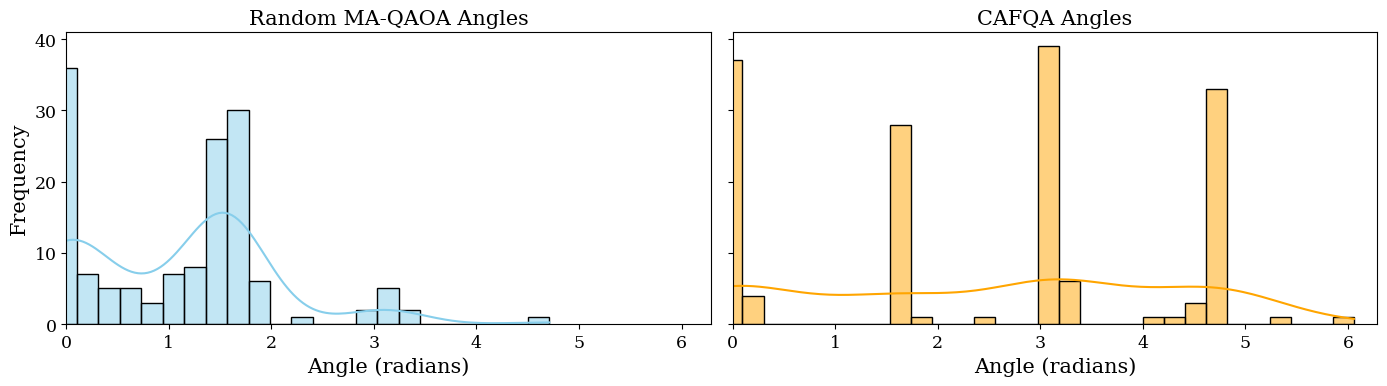

In [14]:
random_fin_angles = cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['result'].x

cafqa_fin_angles = cafqa_diff_points_data['Task_results']['task_1']['result'].x  # Use the provided angles array for CAFQA

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Plot for Random MA-QAOA angles
sns.histplot(random_fin_angles, bins=30, kde=True, color='skyblue', ax=axs[0])
axs[0].set_xlabel('Angle (radians)')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Random MA-QAOA Angles')
axs[0].set_xlim(0, 2 * np.pi)

# Plot for CAFQA angles
sns.histplot(cafqa_fin_angles, bins=30, kde=True, color='orange', ax=axs[1])
axs[1].set_xlabel('Angle (radians)')
axs[1].set_title('CAFQA Angles')
axs[1].set_xlim(0, 2 * np.pi)

plt.tight_layout()
plt.show()

In [15]:
# Generate and print the relative errors for Random MA-QAOA and CAFQA (best of 4) for a single instance
num_qubits = 12  # or any value you want to analyze
i = 1
  # instance index

data = np.load(f'../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/Median_Random_Angles/{num_qubits}_qbs/result_{i}.npy', allow_pickle=True).item()
exact_energy = data['Exact_Ground_State_Energy']
random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
min_cafqa_fin_energy = min(
    data['Task_results'][task]['final_energy']
    for task in data['Task_results'] if task.startswith('task_')
)
random_err = abs((exact_energy - random_fin_energy) / exact_energy)
cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)

print("Random MA-QAOA relative error:", random_err)
print("CAFQA (best of 4) relative error:", cafqa_err)


Random MA-QAOA relative error: 0.166671403651369
CAFQA (best of 4) relative error: 0.09375030982180674


In [16]:
def compute_cafqa_vs_random_stats(num_qubits):
    random_approx_ratios = []
    cafqa_approx_ratios = []
    cafqa_accuracies = []
    random_relative_errors = []
    cafqa_relative_errors = []

    for i in range(1, 6):
        data = np.load(f'../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/{num_qubits}_qbs/result_{i}.npy', allow_pickle=True).item()
        random_ratio = data['Task_results']['Random_MA-QAOA']['approx_ratio']
        random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
        random_approx_ratios.append(random_ratio)
        exact_energy = data['Exact_Ground_State_Energy']
        max_approx_ratio = max(
            data['Task_results'][task]['approx_ratio']
            for task in data['Task_results'] if task.startswith('task_')
        )

        min_cafqa_fin_energy = min(
            data['Task_results'][task]['final_energy']
            for task in data['Task_results'] if task.startswith('task_')
        )

        random_err = abs((exact_energy - random_fin_energy) / exact_energy)
        cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)
        random_relative_errors.append(random_err)
        cafqa_relative_errors.append(cafqa_err)

        cafqa_approx_ratios.append(max_approx_ratio)

        cafqa_accuracy = data['CAFQA_initialization_energy'] / exact_energy
        cafqa_accuracies.append(cafqa_accuracy)

    random_std = np.std(random_approx_ratios)
    cafqa_std = np.std(cafqa_approx_ratios)
    random_relerr_std = np.std(random_relative_errors)
    cafqa_relerr_std = np.std(cafqa_relative_errors)

    avg_random_approx_ratio = gmean(random_approx_ratios)
    avg_cafqa_approx_ratio = gmean(cafqa_approx_ratios)

    avg_random_relative_error = gmean(random_relative_errors)
    avg_cafqa_relative_error = gmean(cafqa_relative_errors)
    
    mean_cafqa_accuracy = gmean(cafqa_accuracies)

    print(f"Geometric mean CAFQA accuracy: {mean_cafqa_accuracy:.4f}")
    print(f"Random MA-QAOA: {avg_random_approx_ratio:.4f} ± {random_std:.4f}")
    print(f"CAFQA (best of 4): {avg_cafqa_approx_ratio:.4f} ± {cafqa_std:.4f}")
    print(f"Geometric mean relative error (Random MA-QAOA vs exact): {avg_random_relative_error:.4f} ± {random_relerr_std:.4f}")
    print(f"Geometric mean relative error (CAFQA best vs exact): {avg_cafqa_relative_error:.4f} ± {cafqa_relerr_std:.4f}")
    return {
        'mean_cafqa_accuracy': mean_cafqa_accuracy,
        'avg_random_approx_ratio': avg_random_approx_ratio,
        'random_std': random_std,
        'avg_cafqa_approx_ratio': avg_cafqa_approx_ratio,
        'cafqa_std': cafqa_std,
        'avg_random_relative_error': avg_random_relative_error,
        'random_relerr_std': random_relerr_std,
        'avg_cafqa_relative_error': avg_cafqa_relative_error,
        'cafqa_relerr_std': cafqa_relerr_std,
    }

compute_cafqa_vs_random_stats(16)

Geometric mean CAFQA accuracy: 0.1820
Random MA-QAOA: 0.8747 ± 0.0158
CAFQA (best of 4): 0.8890 ± 0.0076
Geometric mean relative error (Random MA-QAOA vs exact): 0.6285 ± 0.0635
Geometric mean relative error (CAFQA best vs exact): 0.5632 ± 0.0402


{'mean_cafqa_accuracy': np.float64(0.1819708877767625),
 'avg_random_approx_ratio': np.float64(0.874736225226564),
 'random_std': np.float64(0.015839939917345267),
 'avg_cafqa_approx_ratio': np.float64(0.8889882785294957),
 'cafqa_std': np.float64(0.0076240920544974645),
 'avg_random_relative_error': np.float64(0.6285422302052099),
 'random_relerr_std': np.float64(0.06349897058604002),
 'avg_cafqa_relative_error': np.float64(0.5632176772787963),
 'cafqa_relerr_std': np.float64(0.04018698137711581)}

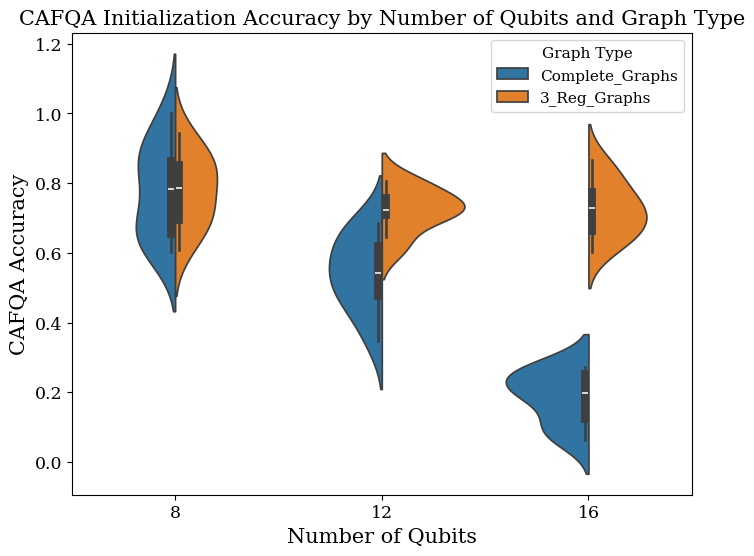

In [17]:


#1000 Gens not 10k 
# Collect CAFQA accuracy data for both Maxcut and K_Reg_Graphs
cafqa_accuracies = []
graph_types = []
num_qubits_col = []

num_qubits_list = [8, 12, 16]
graph_categories = ['Complete_Graphs', '3_Reg_Graphs']

for graph_type in graph_categories:
    for num_qubits in num_qubits_list:
        for idx in range(1, 11):
            if graph_type == 'Complete_Graphs':
                data_path = f'../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/{num_qubits}_qbs/result_{idx}.npy'
            else:
                data_path = f'../np_data/Final_Data_Collection/Maxcut/K_Reg_Graphs/{num_qubits}_qbs/result_{idx}.npy'
            if not os.path.exists(data_path):
                continue
            data = np.load(data_path, allow_pickle=True).item()
            accuracy = data['CAFQA_initialization_energy'] / data['Exact_Ground_State_Energy']
            cafqa_accuracies.append(accuracy)
            graph_types.append(graph_type)
            num_qubits_col.append(num_qubits)

# Create DataFrame for plotting
df = pd.DataFrame({
    'CAFQA Accuracy': cafqa_accuracies,
    'Number of Qubits': num_qubits_col,
    'Graph Type': graph_types
})

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df,
    x='Number of Qubits',
    y='CAFQA Accuracy',
    hue='Graph Type',
    split=True
)
plt.xlabel('Number of Qubits')
plt.ylabel('CAFQA Accuracy')
plt.title('CAFQA Initialization Accuracy by Number of Qubits and Graph Type')
plt.legend(title='Graph Type')
# plt.savefig('../plots/maxcut_cafqa_accuracy_violinplot.png', dpi=500, bbox_inches='tight')
plt.show()

In [18]:
teague_10qb_data = np.load('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()
exact_energy = teague_10qb_data['Exact_Ground_State_Energy'] if 'Exact_Ground_State_Energy' in teague_10qb_data else None

if exact_energy is None:
    # Try to infer from best of all tasks
    exact_energy = min(
        teague_10qb_data['Task_results'][task]['final_energy']
        for task in teague_10qb_data['Task_results']
        if 'final_energy' in teague_10qb_data['Task_results'][task]
    )

random_final_energy = teague_10qb_data['Task_results']['Random_MA-QAOA']['final_energy']
cafqa_final_energy = min(
    teague_10qb_data['Task_results'][task]['final_energy']
    for task in teague_10qb_data['Task_results']
    if task.startswith('task_')
)

random_rel_error = abs((exact_energy - random_final_energy) / exact_energy)
cafqa_rel_error = abs((exact_energy - cafqa_final_energy) / exact_energy)

print(f"Random MA-QAOA relative error: {random_rel_error:.4f}")
print(f"CAFQA (best of 5) relative error: {cafqa_rel_error:.4f}")



Random MA-QAOA relative error: 0.6014
CAFQA (best of 5) relative error: 0.0000


# Knapsack 

In [19]:
def compute_cafqa_vs_random_stats_no_approx(num_items):
    random_relative_error = 0 
    cafqa_relative_error = 0

    cafqa_accuracies = []
    random_relative_errors = []
    cafqa_relative_errors = []

    for i in range(1, 11):
        data = np.load(f'../np_data/Final_Data_Collection/Knapsack/{num_items}_items/result_{i}.npy', allow_pickle=True).item()
        random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
        exact_energy = data['Exact_Ground_State_Energy']

        min_cafqa_fin_energy = min(
            data['Task_results'][task]['final_energy']
            for task in data['Task_results'] if task.startswith('task_')
        )

        random_err = abs((exact_energy - random_fin_energy) / exact_energy)
        cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)
        random_relative_error += random_err
        cafqa_relative_error += cafqa_err
        random_relative_errors.append(random_err)
        cafqa_relative_errors.append(cafqa_err)

        cafqa_accuracy = data['CAFQA_initialization_energy'] / exact_energy
        cafqa_accuracies.append(cafqa_accuracy)

    random_relerr_std = np.std(random_relative_errors)
    cafqa_relerr_std = np.std(cafqa_relative_errors)

    avg_random_relative_error = random_relative_error / 10
    avg_cafqa_relative_error = cafqa_relative_error / 10
    
    mean_cafqa_accuracy = np.mean(cafqa_accuracies)

    print(f"Mean CAFQA accuracy: {mean_cafqa_accuracy:.4f}")
    print(f"Mean relative error (Random MA-QAOA vs exact): {avg_random_relative_error:.4f} ± {random_relerr_std:.4f}")
    print(f"Mean relative error (CAFQA best vs exact): {avg_cafqa_relative_error:.4f} ± {cafqa_relerr_std:.4f}")
    return {
        'mean_cafqa_accuracy': mean_cafqa_accuracy,
        'avg_random_relative_error': avg_random_relative_error,
        'random_relerr_std': random_relerr_std,
        'avg_cafqa_relative_error': avg_cafqa_relative_error,
        'cafqa_relerr_std': cafqa_relerr_std,
    }

compute_cafqa_vs_random_stats_no_approx(12)

Mean CAFQA accuracy: 0.2068
Mean relative error (Random MA-QAOA vs exact): 0.4652 ± 0.1295
Mean relative error (CAFQA best vs exact): 0.3541 ± 0.0904


{'mean_cafqa_accuracy': np.float64(0.20675407362967385),
 'avg_random_relative_error': np.float64(0.4651799829655648),
 'random_relerr_std': np.float64(0.1295249717139555),
 'avg_cafqa_relative_error': np.float64(0.3541041589057981),
 'cafqa_relerr_std': np.float64(0.09036136333119064)}

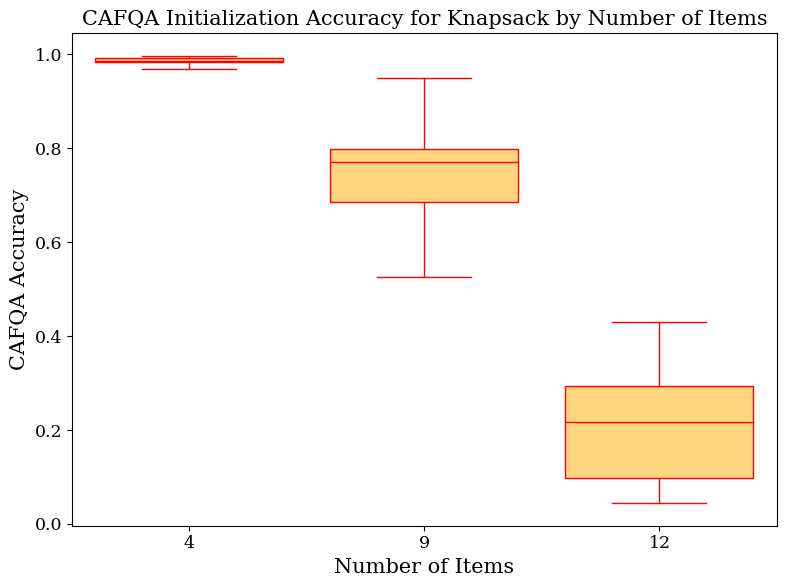

<Axes: xlabel='Number of Items', ylabel='CAFQA Accuracy'>

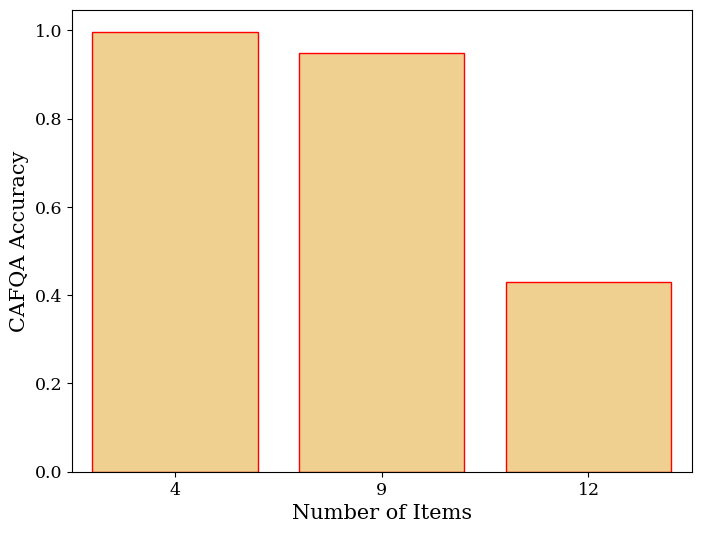

In [20]:
# Collect CAFQA accuracy data for Knapsack with different item sizes
cafqa_accuracies = []
item_sizes = []

item_sizes_list = [4, 9, 12]

for num_items in item_sizes_list:
    for idx in range(1, 11):
        data_path = f'../np_data/Final_Data_Collection/Knapsack/{num_items}_items/result_{idx}.npy'
        if not os.path.exists(data_path):
            continue
        data = np.load(data_path, allow_pickle=True).item()
        accuracy = data['CAFQA_initialization_energy'] / data['Exact_Ground_State_Energy']
        cafqa_accuracies.append(accuracy)
        item_sizes.append(num_items)

# Create DataFrame for plotting
df_knapsack = pd.DataFrame({
    'CAFQA Accuracy': cafqa_accuracies,
    'Number of Items': item_sizes
})

# Custom boxplot with light orange color
sns.boxplot(
    data=df_knapsack,
    x='Number of Items',
    y='CAFQA Accuracy',
    boxprops=dict(facecolor='#FFD580', edgecolor='red'),  # light orange hex
    medianprops=dict(color='red'),
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    flierprops=dict(marker='o', color='red', markeredgecolor='red')
)

plt.xlabel('Number of Items')
plt.ylabel('CAFQA Accuracy')
plt.title('CAFQA Initialization Accuracy for Knapsack by Number of Items')
# plt.savefig('../plots/knapsack_cafqa_accuracy_boxplot.png', dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Compute the maximum CAFQA accuracy for each item size
max_accuracies = df_knapsack.groupby('Number of Items')['CAFQA Accuracy'].max().reset_index()

# Barplot of max accuracy for each item size
sns.barplot(
    data=max_accuracies,
    x='Number of Items',
    y='CAFQA Accuracy',
    color='#FFD580',
    edgecolor='red'
)


## Emperical Evidence

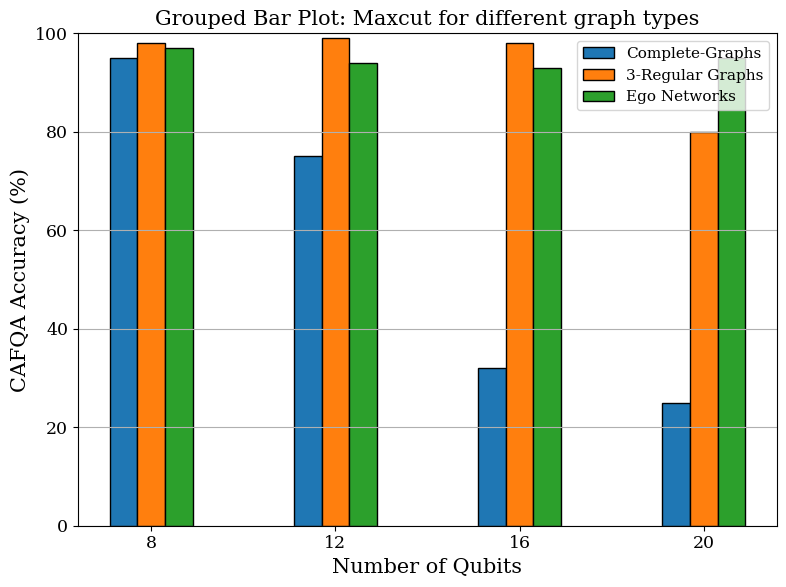

In [21]:
# Example data for 3 bars per qubit size
num_qubits = [8, 12, 16, 20]
bar_labels = ['Complete-Graphs', '3-Regular Graphs', 'Ego Networks']
# Dummy means for illustration; replace with your actual data
data = [
    [0.95, 0.75, 0.32, 0.25 ],  # Complete
    [0.98, 0.99, 0.98, 0.8 ],  # 3_Reg
    [0.97, 0.94, 0.93, 0.95]   # Ego Networks
]
data = np.array(data)  # shape (3, 3)

bar_width = 0.15
index = np.arange(len(num_qubits))

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(3):
    ax.bar(index + (i - 1) * bar_width, data[i], bar_width, label=bar_labels[i],edgecolor='black')
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_yticklabels([f"{int(100*y)}" for y in np.arange(0, 1.1, 0.2)])
ax.set_xticks(index)
ax.set_xticklabels(num_qubits)
ax.set_xlabel('Number of Qubits')
ax.set_ylabel('CAFQA Accuracy (%)')
ax.set_title('Grouped Bar Plot: Maxcut for different graph types')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

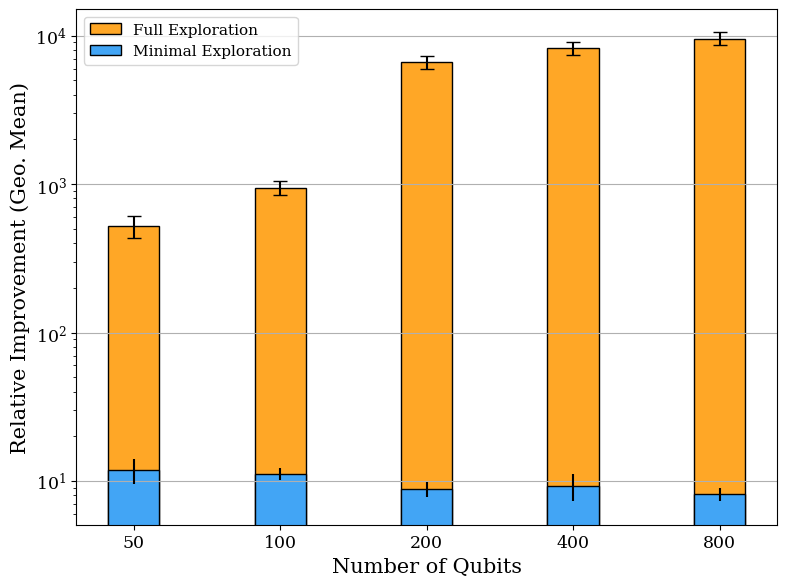

In [22]:
#Really Large Problems 

# Example data for large problems: relative improvement vs random and vs initial Clifford point
item_labels = ["50", "100","200", "400", "800"]
# These values reflect that improvement vs random is ~100x and vs Clifford is ~10x
improvement_vs_random = [520,946,667/0.1,825/0.1,955/0.1]  
improvement_vs_clifford = [11.8,11.2,667/76,9.2,955/117]   

# Calculate standard deviations for each improvement category
std_improvement_vs_random = [90, 102, 670, 825, 955]  # Example standard deviations for improvement vs random
std_improvement_vs_clifford = [2.2, 1.1, 1, 1.9, .8]  # Example standard deviations for improvement vs Clifford

bar_width = 0.35
index = np.arange(len(item_labels))

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(index, improvement_vs_random, bar_width, yerr=std_improvement_vs_random, label='Full Exploration', color='#FFA726', edgecolor='black', capsize=5)
ax.bar(index, improvement_vs_clifford, bar_width, yerr=std_improvement_vs_clifford, label='Minimal Exploration', color='#42A5F5', edgecolor='black')

ax.set_xticks(index)
ax.set_xticklabels(item_labels)
ax.set_xlabel('Number of Qubits',fontsize=BIGGER_SIZE)
ax.set_ylabel('Relative Improvement (Geo. Mean)',fontsize=BIGGER_SIZE)
# ax.set_title('CAFQA Relative Improvement for 3-Regular Maxcut')
ax.legend()
ax.set_yscale('log')
ax.grid(axis='y')
plt.tight_layout()
ax.tick_params(labelsize=MEDIUM_SIZE)
# fig.savefig("../plots/Cafqa_accuracy_large_maxcut.pdf", dpi=800, bbox_inches='tight')
plt.show()

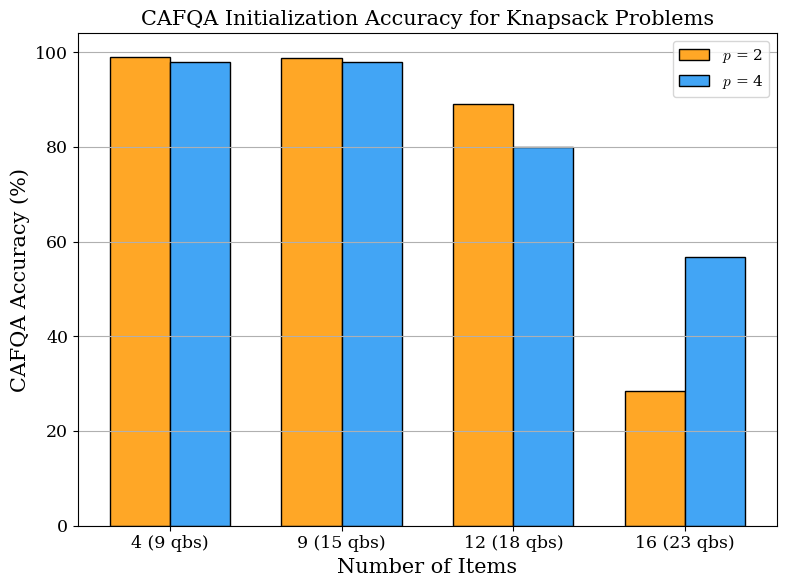

In [23]:
# CAFQA initialization accuracy for Knapsack: p=2 vs p=4

item_sizes = [4, 9, 12, 16]
layers = [2, 4]
dummy_accuracies = {
    (4, 2): 0.99, (4, 4): 0.98,
    (9, 2): 44194/44800.5, (9, 4): 43860/44800.5,
    (12, 2): 148133.5/166236.5, (12, 4): 132867/166326.5,
    (16, 2): 91840/323296.5, (16,    4): 183680/323296.5
}

bar_width = 0.35
index = np.arange(len(item_sizes))

layer1 = [dummy_accuracies[(n, 2)] * 100 for n in item_sizes]
layer2 = [dummy_accuracies[(n, 4)] * 100 for n in item_sizes]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(index - bar_width/2, layer1, bar_width, label='$p$ = 2', color='#FFA726',edgecolor='black')
ax.bar(index + bar_width/2, layer2, bar_width, label='$p$ = 4', color='#42A5F5',edgecolor='black')

ax.set_xticks(index)
ax.set_xticklabels(["4 (9 qbs)", "9 (15 qbs)", "12 (18 qbs)", "16 (23 qbs)"])
ax.set_xlabel('Number of Items')
ax.set_ylabel('CAFQA Accuracy (%)')
ax.set_title('CAFQA Initialization Accuracy for Knapsack Problems')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

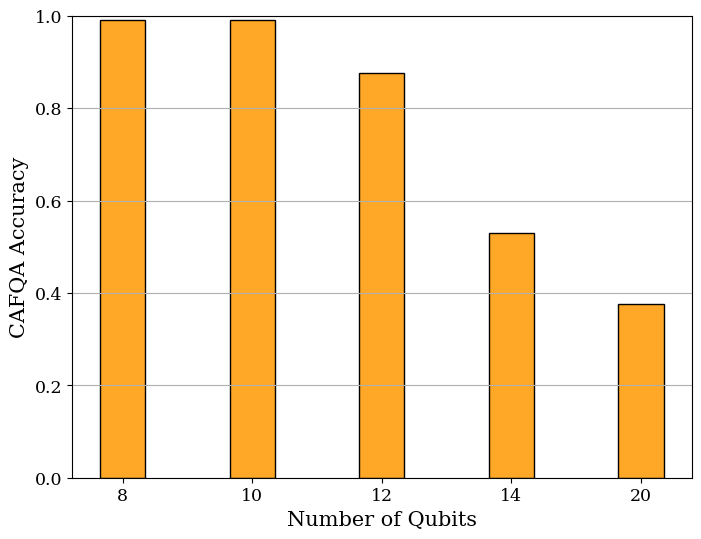

In [24]:
# Use custom accuracy values instead of extracting from df
selected_qubits = [8, 10, 12 , 14 , 20]
custom_accuracies = [0.99, 0.99, 0.875 , 0.53 , 0.375]  # example values, replace with your own

plt.bar([str(q) for q in selected_qubits], custom_accuracies, color='#FFA726', edgecolor='black',width=0.35)
plt.xlabel('Number of Qubits')
plt.ylabel('CAFQA Accuracy')
# plt.title('CAFQA Accuracy for Cancer Genomics Dataset')
plt.ylim(0, 1)
plt.gca().set_ylim(0, 1)
plt.gca().set_yticks(np.linspace(0, 1, 6))
plt.gca().set_yticklabels([f"{y:.1f}" for y in np.linspace(0, 1, 6)])
plt.grid(axis='y')
# plt.savefig("../plots/Cafqa_accuracy_teague.pdf", dpi=800, bbox_inches='tight')
plt.show()


In [25]:
# lets build the dataframe for the data required for the maxcut-accuracy plot

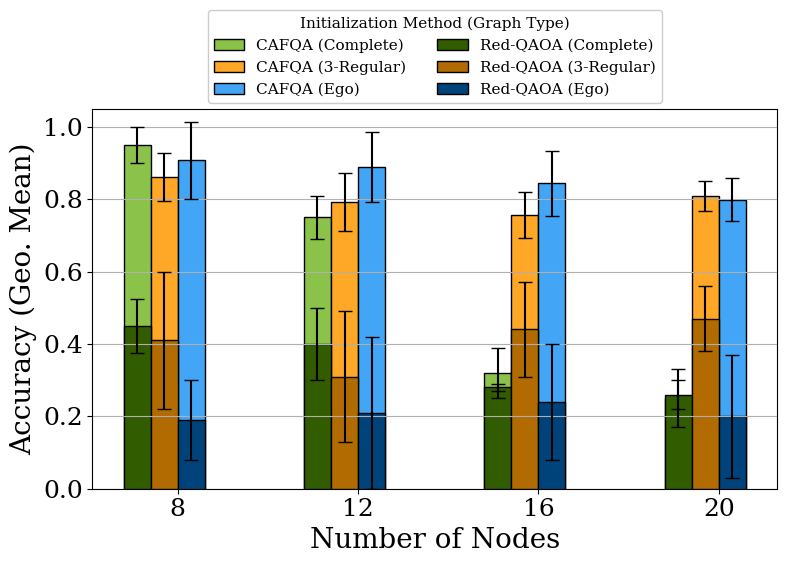

In [26]:
def find_min_fitness_in_log(log_file_path):
    min_fitness = None
    exact_energy = None
    pattern_fitness = re.compile(r"GENERATION\s+\d+:\s+BEST FITNESS FOUND\s+:\s+(-?\d+\.?\d*)")
    pattern_exact_energy = re.compile(r"Exact Energy from Eigensolver:\s+(-?\d+\.?\d*)")
    with open(log_file_path, 'r') as f:
        for line in f:
            match_fitness = pattern_fitness.search(line)
            if match_fitness:
                try:
                    fitness_val = float(match_fitness.group(1))
                    if min_fitness is None or fitness_val < min_fitness:
                        min_fitness = fitness_val
                except ValueError:
                    continue
            match_exact = pattern_exact_energy.search(line)
            if match_exact:
                try:
                    exact_energy = float(match_exact.group(1))
                except ValueError:
                    continue
    return min_fitness/exact_energy

def compute_folder_accuracy_stats(folder_path):
    log_files = glob.glob(os.path.join(folder_path, "*.log"))
    accuracies = []
    for log_file in log_files:
        try:
            acc = find_min_fitness_in_log(log_file)
            if acc is not None:
                accuracies.append(acc)
        except Exception as e:
            print(f"Error processing {log_file}: {e}")
    if len(accuracies) == 0:
        print("No valid log files found.")
        return None
    gmean_acc = gmean(accuracies)
    std_acc = np.std(accuracies)
    return gmean_acc, std_acc

def get_cafqa_accuracy_df(graph_type):
    qubit_list = [8, 12, 16, 20]
    gmeans = []
    stds = []
    for n in qubit_list:
        folder = f"../logs/Comprehensive_Proof/Maxcut/{graph_type}/2_reps/{n}/"
        result = compute_folder_accuracy_stats(folder)
        if result is not None:
            gmeans.append(result[0])
            stds.append(result[1])
        else:
            gmeans.append(np.nan)
            stds.append(np.nan)
    df_kreg_accuracy = pd.DataFrame({
        "Number of Qubits": qubit_list,
        "Geometric Mean CAFQA Accuracy": gmeans,
        "Std CAFQA Accuracy": stds
    })
    return df_kreg_accuracy

# Example usage:
df_kreg_accuracy = get_cafqa_accuracy_df("K_Regular_Graphs")
df_ego_graphs = get_cafqa_accuracy_df("Ego_Graphs")

# Create DataFrame for Complete Graphs accuracies
df_complete_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [0.95, 0.75, 0.32, 0.25],
    "Std CAFQA Accuracy": [0.05, 0.06, 0.07, 0.08]  # No std provided, set to 0
})

#Red-QAOA weighted results 

and_ratios = [0.75, 0.5, 0.25, 0.10]

# Update each row with specific data for each ratio
df_kreg_accuracy["Geometric Mean Red-QAOA Accuracy (AND=0.75)"] = [0.41, 0.31, 0.44, 0.47]
df_kreg_accuracy["Std Red-QAOA Accuracy (AND=0.75)"] = [0.19, 0.18, 0.13, 0.09]

df_kreg_accuracy["Geometric Mean Red-QAOA Accuracy (AND=0.5)"] = [0.25,0.20,0.23,0.18]
df_kreg_accuracy["Std Red-QAOA Accuracy (AND=0.5)"] = [0.1,0.13,0.2,0.13]

df_kreg_accuracy["Geometric Mean Red-QAOA Accuracy (AND=0.25)"] = [0.3,0.12,0.16,0.212]
df_kreg_accuracy["Std Red-QAOA Accuracy (AND=0.25)"] = [0.14,0.06,0.1,0.045]

df_kreg_accuracy["Geometric Mean Red-QAOA Accuracy (AND=0.10)"] = [0.3,0.21,0.19,0.21]
df_kreg_accuracy["Std Red-QAOA Accuracy (AND=0.10)"] = [0.09, 0.08, 0.06, 0.05]

df_ego_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.75)"] = [0.19,0.21,0.24,0.2]
df_ego_graphs["Std Red-QAOA Accuracy (AND=0.75)"] = [0.11, 0.21, 0.16, 0.17]

df_ego_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.5)"] = [0.303,0.1,0.12,0.2]
df_ego_graphs["Std Red-QAOA Accuracy (AND=0.5)"] = [0.152,0.06,0.13,0.17]

df_ego_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.25)"] = [0.14,0.2,0.1,0.1]
df_ego_graphs["Std Red-QAOA Accuracy (AND=0.25)"] = [0.02,0.12,0.05,0.14]

df_ego_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.10)"] = [0.19,0.217,0.12,0.11]
df_ego_graphs["Std Red-QAOA Accuracy (AND=0.10)"] = [0.08,0.08,0.02,0.01]

df_complete_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.75)"] = [0.45,0.4,0.28,0.26]
df_complete_graphs["Std Red-QAOA Accuracy (AND=0.75)"] = [0.074, 0.10, 0.01, 0.04]

df_complete_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.5)"] = [0.4,0.31,0.28,0.23]
df_complete_graphs["Std Red-QAOA Accuracy (AND=0.5)"] = [0.06,0.04,0.03,0.12]

df_complete_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.25)"] = [0.2,0.11,0.1,0.07]
df_complete_graphs["Std Red-QAOA Accuracy (AND=0.25)"] = [0.07,0.07,0.05,0.04]

df_complete_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.10)"] = [0.15,0.04,0.02,0.009]
df_complete_graphs["Std Red-QAOA Accuracy (AND=0.10)"] = [0.06,0.014,0.015,0.01]



# Grouped bar plot for geometric mean CAFQA accuracy for K-Regular and Ego Graphs
x = np.arange(len(df_kreg_accuracy["Number of Qubits"]))  # group positions
bar_width = 0.15

fig, ax = plt.subplots(figsize=(8, 6))
# Use this DataFrame in the barplot for Complete Graphs
ax.bar(x - bar_width*1.5, df_complete_graphs["Geometric Mean CAFQA Accuracy"], 
    bar_width, yerr=df_complete_graphs["Std CAFQA Accuracy"], 
    label="Complete Graphs", color="#8BC34A", capsize=5, edgecolor="black")
ax.bar(x - bar_width/2, df_kreg_accuracy["Geometric Mean CAFQA Accuracy"], 
    bar_width, yerr=df_kreg_accuracy["Std CAFQA Accuracy"], 
    label="3-Regular Graphs", color="#FFA726", capsize=5, edgecolor="black")
ax.bar(x + bar_width/2, df_ego_graphs["Geometric Mean CAFQA Accuracy"], 
    bar_width, yerr=df_ego_graphs["Std CAFQA Accuracy"], 
    label="Ego Graphs", color="#42A5F5", capsize=5, edgecolor="black")

ax.legend(
    [
        "Complete Graphs", 
        "3-Regular Graphs", 
        "Ego Graphs", 
    ], 
    loc="upper center", 
    fontsize=11, 
    frameon=True, 
    ncol=3, 
    title="Graph Type", 
    bbox_to_anchor=(0.5, 1.15),
    framealpha=1
)


# Plot with Red-QAOA
# Add scatter plot with error bars for Red-QAOA accuracies
# Add bar plots for Red-QAOA accuracies
ax.bar(
    x - bar_width*1.5, 
    df_complete_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.75)"], 
    bar_width, yerr=df_complete_graphs["Std Red-QAOA Accuracy (AND=0.75)"], 
    label="Red-QAOA (Complete Graphs)", color="#315C00", capsize=5, edgecolor="black"
)
ax.bar(
    x - bar_width/2, 
    df_kreg_accuracy["Geometric Mean Red-QAOA Accuracy (AND=0.75)"], 
    bar_width, yerr=df_kreg_accuracy["Std Red-QAOA Accuracy (AND=0.75)"], 
    label="Red-QAOA (3-Regular Graphs)", color="#B26B00", capsize=5, edgecolor="black"
)
ax.bar(
    x + bar_width/2, 
    df_ego_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.75)"], 
    bar_width, yerr=df_ego_graphs["Std Red-QAOA Accuracy (AND=0.75)"], 
    label="Red-QAOA (Ego Graphs)", color="#00437B", capsize=5, edgecolor="black"
)
ax.legend(
    [
        "CAFQA (Complete)", 
        "CAFQA (3-Regular)", 
        "CAFQA (Ego)", 
        "Red-QAOA (Complete)", 
        "Red-QAOA (3-Regular)", 
        "Red-QAOA (Ego)", 
    ], 
    loc="upper center", 
    fontsize=11, 
    frameon=True, 
    ncol=2, 
    title="Initialization Method (Graph Type)", 
    bbox_to_anchor=(0.5, 1.28),
    framealpha=1
)

ax.set_xticks(x)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xticklabels(df_kreg_accuracy["Number of Qubits"])
ax.set_xlabel("Number of Nodes", fontsize=20)
ax.set_ylabel("Accuracy (Geo. Mean)", fontsize=20)
# ax.set_title("CAFQA Accuracy by Graph Type and Number of Qubits")
ax.set_ylim(0, 1.05)
ax.grid(axis='y')
plt.tight_layout()
ax.get_legend()
plt.show()
# fig.savefig("../plots/Cafqa_accuracy_maxcut.pdf", dpi=800, bbox_inches='tight')

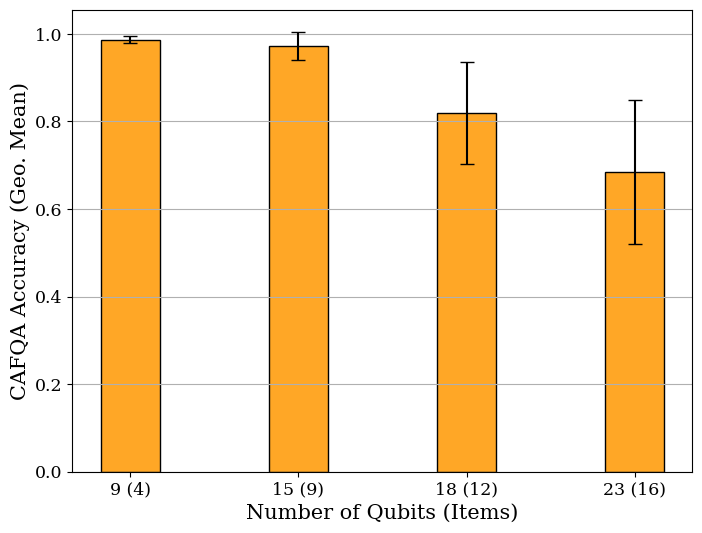

In [27]:
# Calculate mean and standard deviation for each qubit count
num_items_list = [4,9,12,16]
cafqa_accuracies = []

means = []
stds = []
for num_qubits in num_items_list:
    accs = []
    for idx in range(0, 8):
        data_path = f'../np_data/Comprehensive_Proof/Knapsack/2_reps/{num_qubits}_qbs/results_{idx}.npy'
        data = np.load(data_path, allow_pickle=True).item()
        acc = data['CAFQA_initialization_energy'] / data['exact_energy']
        accs.append(acc)
    means.append(np.mean(accs))
    stds.append(np.std(accs))

plt.figure(figsize=(8, 6))
# Only top error bars: bottom error = 0, top error = stds
plt.bar([str(q) for q in num_items_list], means, yerr=stds, color='#FFA726', edgecolor='black', capsize=5,width=0.35)
plt.xlabel('Number of Qubits (Items)')
plt.ylabel('CAFQA Accuracy (Geo. Mean)')
# plt.title('Mean CAFQA Initialization Accuracy (Knapsack)')
plt.xticks(
    range(len(num_items_list)),
    [f"{items} ({qbs})" for items, qbs in zip([9,15,18,23], num_items_list)]
)
plt.grid(axis='y')
# plt.savefig("../plots/Cafqa_accuracy_knapsack.pdf", dpi=800, bbox_inches='tight')
plt.show()

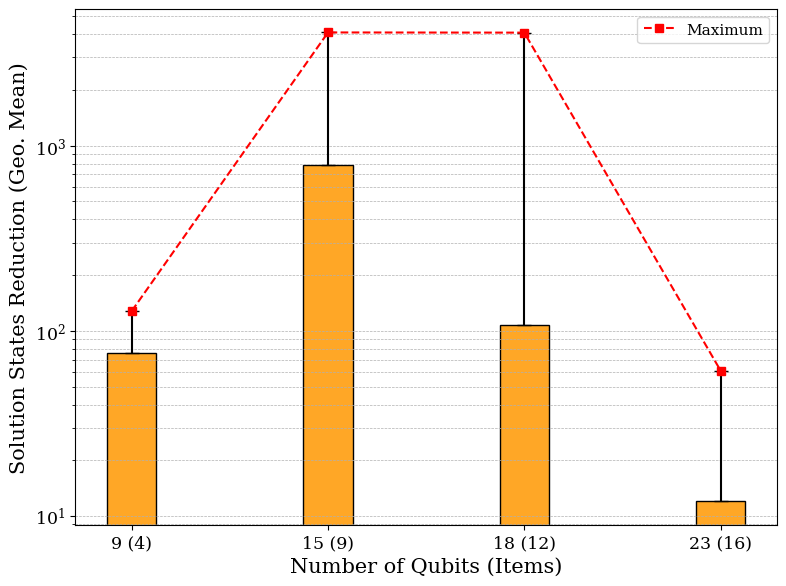

In [28]:
# Statevec Reduction - Knapsack 

num_items_list = [4, 9, 12, 16]
avg_values = [76, 789, 107, 12]
max_values = [128, 4095, 4085, 61]

x = np.arange(len(num_items_list))
bar_width = 0.25

# Calculate top error as (max - avg), bottom error as 0
yerr = [np.zeros(len(avg_values)), np.array(max_values) - np.array(avg_values)]

plt.bar(x, avg_values, bar_width, color='#FFA726', edgecolor='black', yerr=yerr, capsize=5)
plt.yscale('log')
plt.xlabel('Number of Qubits (Items)')
plt.ylabel('Solution States Reduction (Geo. Mean)')
plt.legend()
plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.xticks(
    x,
    [f"{items} ({qbs})" for items, qbs in zip([9, 15, 18, 23], num_items_list)]
)

# Connect the top of the error bars (i.e., the max values) with a line
plt.plot(x, max_values, 'rs--', label='Maximum')
plt.legend()
# plt.savefig("../plots/statevector_reduction_knapsack.pdf", dpi=800, bbox_inches='tight')
plt.show()

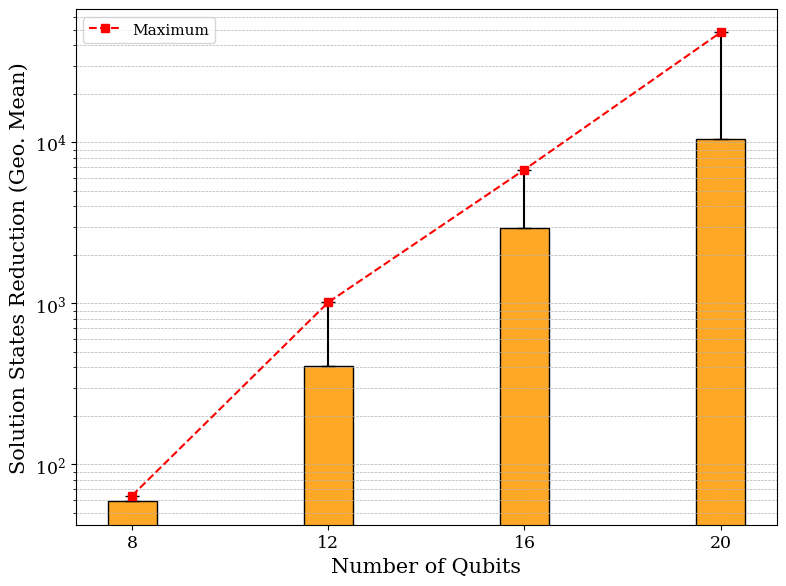

In [29]:
# Statevec Reduction - K_Reg 

num_items_list = [8, 12, 16, 20]
avg_values = [59, 409, 2945, 10448]
max_values = [64, 1015, 6770, 48132]

x = np.arange(len(num_items_list))
bar_width = 0.25

# Calculate top error as (max - avg), bottom error as 0
yerr = [np.zeros(len(avg_values)), np.array(max_values) - np.array(avg_values)]

bars = plt.bar(x, avg_values, bar_width, color='#FFA726', edgecolor='black', yerr=yerr, capsize=5)
plt.yscale('log')
plt.xlabel('Number of Qubits')
plt.ylabel('Solution States Reduction (Geo. Mean)')
plt.legend()
plt.xticks(
    x,
    [str(q) for q in num_items_list]
)
plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Connect the top of the error bars (i.e., the max values) with a line
plt.plot(x, max_values, 'rs--', label='Maximum')
plt.legend()

# plt.savefig("../plots/statevector_reduction_k_reg.pdf", dpi=800, bbox_inches='tight')
plt.show()

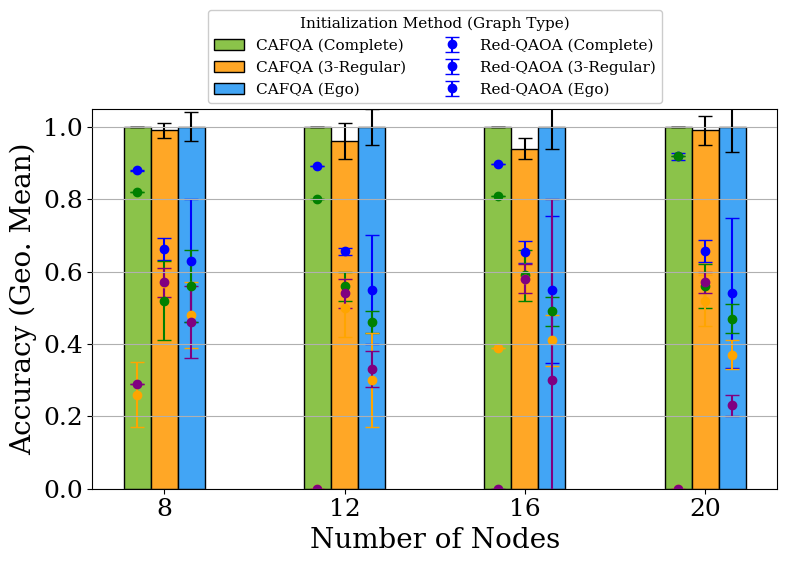

In [30]:
# Unweighted Red-QAOA comparision
# Placeholder values for Geometric Mean Red-QAOA Accuracy with AND=0.75, 0.5, 0.25, and 0.10
df_ego_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],  # Placeholder values
    "Std CAFQA Accuracy": [0.04, 0.05, 0.06, 0.07],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.75)": [0.63, 0.55, 0.55, 0.54],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.75)": [0.17, 0.15, 0.203, 0.207],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.5)": [0.56,.46,0.49,0.47],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.5)": [0.1,0.03,0.04,0.04],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.25)": [0.48,0.3,0.41,0.37],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.25)": [0.09,0.13,0.07,0.04],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.10)": [0.46,0.33,0.3,0.23],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.10)": [0.1,0.05,0.5,0.03],  # Placeholder standard deviations
})

df_kreg_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [0.99, 0.96, 0.94, 0.99],  # Placeholder values
    "Std CAFQA Accuracy": [0.02, 0.05, 0.03, 0.04],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.75)": [0.662, 0.656, 0.655, 0.656],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.75)": [0.03, 0.01, 0.03, 0.03],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.5)": [0.52,0.56,0.59,0.56],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.5)": [0.11,0.04,0.07,0.06],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.25)": [0.568,0.5,0.58,0.52],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.25)": [0.04,0.08,0.04,0.07],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.10)": [0.57,0.54,0.58,0.57],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.10)": [0.04,0.04,0.04,0.03],  # Placeholder standard deviations
})

df_complete_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],  # Placeholder values
    "Std CAFQA Accuracy": [0, 0, 0, 0],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.75)": [0.88, 0.892, 0.898, 0.919],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.75)": [0.001, 1.1e-16, 4.21e-16, 0.01],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.5)": [0.82,0.80,0.81,0.92],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.5)": [0.0008,1e-16,1e-16,1e-16],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.25)": [0.26,1e-6,0.39,1e-6],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.25)": [0.09,1e-22,1e-16,1e-16],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.10)": [0.29,1e-6,1e-6,1e-6],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.10)": [1e-6,1e-6,1e-21,1e-6],  # Placeholder standard deviations
})

# Create placeholder DataFrames for Ego Graphs and K-Regular Graphs accuracies
# df_ego_graphs = pd.DataFrame({
#     "Number of Qubits": [8, 12, 16, 20],
#     "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],  # Placeholder values #NOTE: can be increased 
#     "Std CAFQA Accuracy": [0.04, 0.05, 0.06, 0.07],  # Placeholder standard deviations
#     "Geometric Mean Red-QAOA Accuracy": [0.63, 0.55, 0.55, 0.54],  # Placeholder values
#     "Std Red-QAOA Accuracy": [0.17, 0.15, 0.203, 0.207]  # Placeholder standard deviations
# })

# df_kreg_graphs = pd.DataFrame({
#     "Number of Qubits": [8, 12, 16, 20],
#     "Geometric Mean CAFQA Accuracy": [0.99, 0.96, 0.94, 0.99],  # Placeholder values
#     "Std CAFQA Accuracy": [0.02, 0.05, 0.03, 0.04],  # Placeholder standard deviations
#     "Geometric Mean Red-QAOA Accuracy": [0.662, 0.656, 0.655, 0.656],  # Placeholder values
#     "Std Red-QAOA Accuracy": [0.03, 0.01, 0.03, 0.03]  # Placeholder standard deviations
# })

# # Create DataFrame for Complete Graphs accuracies
# df_complete_graphs = pd.DataFrame({
#     "Number of Qubits": [8, 12, 16, 20],
#     "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],
#     "Std CAFQA Accuracy": [0, 0, 0, 0],  # Placeholder standard deviations
#     "Geometric Mean Red-QAOA Accuracy": [0.88, 0.892, 0.898, 0.919],  # Placeholder values #NOTE: todo
#     "Std Red-QAOA Accuracy": [0.001, 1.1e-16, 4.21e-16, 0.01]  # Placeholder standard deviations 
# })


# Grouped bar plot for geometric mean CAFQA accuracy for K-Regular and Ego Graphs
x = np.arange(len(df_kreg_accuracy["Number of Qubits"]))  # group positions
bar_width = 0.15

fig, ax = plt.subplots(figsize=(8, 6))
# ensure grid and axis stacking so lines can be drawn on top
ax.set_axisbelow(False)

# CAFQA bars
ax.bar(x - bar_width, df_complete_graphs["Geometric Mean CAFQA Accuracy"], 
    bar_width, yerr=df_complete_graphs["Std CAFQA Accuracy"], 
    label="Complete Graphs", color="#8BC34A", capsize=5, edgecolor="black")
ax.bar(x, df_kreg_graphs["Geometric Mean CAFQA Accuracy"], 
    bar_width, yerr=df_kreg_graphs["Std CAFQA Accuracy"], 
    label="3-Regular Graphs", color="#FFA726", capsize=5, edgecolor="black")
ax.bar(x + bar_width, df_ego_graphs["Geometric Mean CAFQA Accuracy"], 
    bar_width, yerr=df_ego_graphs["Std CAFQA Accuracy"], 
    label="Ego Graphs", color="#42A5F5", capsize=5, edgecolor="black")

# Red-QAOA error bars for all AND ratios
and_ratios = ['0.75', '0.5', '0.25', '0.10']
colors = ['blue', 'green', 'orange', 'purple']
for i, and_ratio in enumerate(and_ratios):
    ax.errorbar(
        x - bar_width,
        df_complete_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={and_ratio})"],
        yerr=df_complete_graphs[f"Std Red-QAOA Accuracy (AND={and_ratio})"],
        fmt='o', color=colors[i], label=f"Red-QAOA (Complete, AND={and_ratio})", capsize=5
    )
    ax.errorbar(
        x,
        df_kreg_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={and_ratio})"],
        yerr=df_kreg_graphs[f"Std Red-QAOA Accuracy (AND={and_ratio})"],
        fmt='o', color=colors[i], label=f"Red-QAOA (3-Regular, AND={and_ratio})", capsize=5
    )
    ax.errorbar(
        x + bar_width,
        df_ego_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={and_ratio})"],
        yerr=df_ego_graphs[f"Std Red-QAOA Accuracy (AND={and_ratio})"],
        fmt='o', color=colors[i], label=f"Red-QAOA (Ego, AND={and_ratio})", capsize=5
    )
# # Red-QAOA error bars only
# ax.errorbar(
#     x - bar_width, 
#     df_complete_graphs["Geometric Mean Red-QAOA Accuracy"], 
#     yerr=df_complete_graphs["Std Red-QAOA Accuracy"], 
#     fmt='o', color='blue', label="Red-QAOA (Complete Graphs)", capsize=5
# )
# ax.errorbar(
#     x, 
#     df_kreg_graphs["Geometric Mean Red-QAOA Accuracy"], 
#     yerr=df_kreg_graphs["Std Red-QAOA Accuracy"], 
#     fmt='o', color='black', label="Red-QAOA (3-Regular Graphs)", capsize=5
# )
# ax.errorbar(
#     x + bar_width, 
#     df_ego_graphs["Geometric Mean Red-QAOA Accuracy"], 
#     yerr=df_ego_graphs["Std Red-QAOA Accuracy"], 
#     fmt='o', color='red', label="Red-QAOA (Ego Graphs)", capsize=5
# )

ax.set_xticks(x)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xticklabels(df_kreg_accuracy["Number of Qubits"])
ax.set_xlabel("Number of Nodes", fontsize=20)
ax.set_ylabel("Accuracy (Geo. Mean)", fontsize=20)
# ax.set_title("CAFQA Accuracy by Graph Type and Number of Qubits")

ax.legend(
    [
        "CAFQA (Complete)", 
        "CAFQA (3-Regular)", 
        "CAFQA (Ego)", 
        "Red-QAOA (Complete)", 
        "Red-QAOA (3-Regular)", 
        "Red-QAOA (Ego)", 
    ], 
    loc="upper center", 
    fontsize=11, 
    frameon=True, 
    ncol=2, 
    title="Initialization Method (Graph Type)", 
    bbox_to_anchor=(0.5, 1.28),
    framealpha=1
)
ax.set_ylim(0, 1.05)
ax.grid(axis='y')
plt.tight_layout()
# plt.savefig("../plots/cafqa_accuracy_maxcut_unweighted.pdf", dpi=800, bbox_inches='tight')
plt.show()

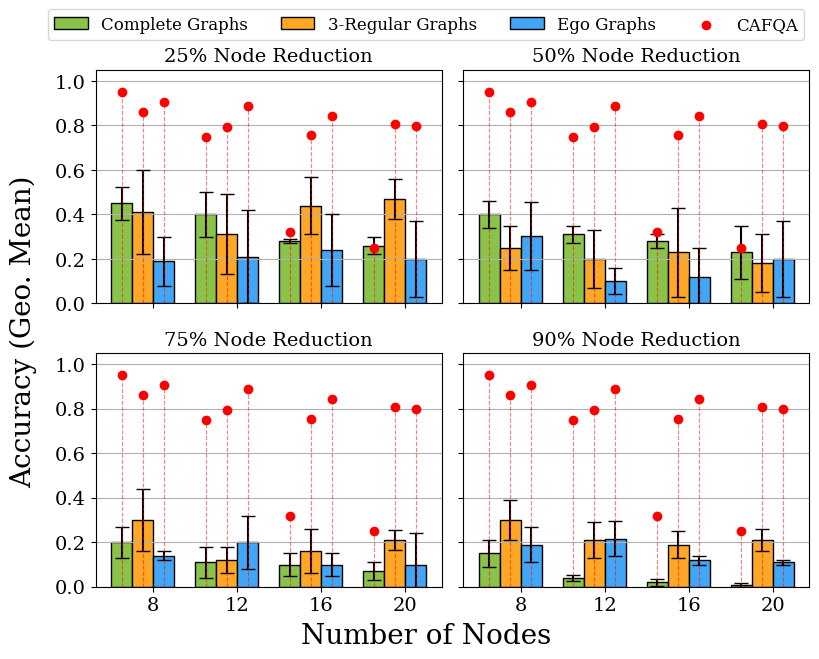

In [31]:
def find_min_fitness_in_log(log_file_path):
    min_fitness = None
    exact_energy = None
    pattern_fitness = re.compile(r"GENERATION\s+\d+:\s+BEST FITNESS FOUND\s+:\s+(-?\d+\.?\d*)")
    pattern_exact_energy = re.compile(r"Exact Energy from Eigensolver:\s+(-?\d+\.?\d*)")
    with open(log_file_path, 'r') as f:
        for line in f:
            match_fitness = pattern_fitness.search(line)
            if match_fitness:
                try:
                    fitness_val = float(match_fitness.group(1))
                    if min_fitness is None or fitness_val < min_fitness:
                        min_fitness = fitness_val
                except ValueError:
                    continue
            match_exact = pattern_exact_energy.search(line)
            if match_exact:
                try:
                    exact_energy = float(match_exact.group(1))
                except ValueError:
                    continue
    return min_fitness/exact_energy

def compute_folder_accuracy_stats(folder_path):
    log_files = glob.glob(os.path.join(folder_path, "*.log"))
    accuracies = []
    for log_file in log_files:
        try:
            acc = find_min_fitness_in_log(log_file)
            if acc is not None:
                accuracies.append(acc)
        except Exception as e:
            print(f"Error processing {log_file}: {e}")
    if len(accuracies) == 0:
        print("No valid log files found.")
        return None
    gmean_acc = gmean(accuracies)
    std_acc = np.std(accuracies)
    return gmean_acc, std_acc

def get_cafqa_accuracy_df(graph_type):
    qubit_list = [8, 12, 16, 20]
    gmeans = []
    stds = []
    for n in qubit_list:
        folder = f"../logs/Comprehensive_Proof/Maxcut/{graph_type}/2_reps/{n}/"
        result = compute_folder_accuracy_stats(folder)
        if result is not None:
            gmeans.append(result[0])
            stds.append(result[1])
        else:
            gmeans.append(np.nan)
            stds.append(np.nan)
    df_kreg_weighted_graphs = pd.DataFrame({
        "Number of Qubits": qubit_list,
        "Geometric Mean CAFQA Accuracy": gmeans,
        "Std CAFQA Accuracy": stds
    })
    return df_kreg_weighted_graphs

# Example usage:
df_kreg_weighted_graphs = get_cafqa_accuracy_df("K_Regular_Graphs")
df_ego_weighted_graphs = get_cafqa_accuracy_df("Ego_Graphs")

# Create DataFrame for Complete Graphs accuracies
df_complete_weighted_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [0.95, 0.75, 0.32, 0.25],
    "Std CAFQA Accuracy": [0.05, 0.06, 0.07, 0.08]  # No std provided, set to 0
})

#Red-QAOA weighted results 

and_ratios = ['0.75', '0.5', '0.25', '0.10']

# Update each row with specific data for each ratio
df_kreg_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.75)"] = [0.41, 0.31, 0.44, 0.47]
df_kreg_weighted_graphs["Std Red-QAOA Accuracy (AND=0.75)"] = [0.19, 0.18, 0.13, 0.09]

df_kreg_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.5)"] = [0.25,0.20,0.23,0.18]
df_kreg_weighted_graphs["Std Red-QAOA Accuracy (AND=0.5)"] = [0.1,0.13,0.2,0.13]

df_kreg_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.25)"] = [0.3,0.12,0.16,0.212]
df_kreg_weighted_graphs["Std Red-QAOA Accuracy (AND=0.25)"] = [0.14,0.06,0.1,0.045]

df_kreg_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.10)"] = [0.3,0.21,0.19,0.21]
df_kreg_weighted_graphs["Std Red-QAOA Accuracy (AND=0.10)"] = [0.09, 0.08, 0.06, 0.05]

df_ego_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.75)"] = [0.19,0.21,0.24,0.2]
df_ego_weighted_graphs["Std Red-QAOA Accuracy (AND=0.75)"] = [0.11, 0.21, 0.16, 0.17]

df_ego_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.5)"] = [0.303,0.1,0.12,0.2]
df_ego_weighted_graphs["Std Red-QAOA Accuracy (AND=0.5)"] = [0.152,0.06,0.13,0.17]

df_ego_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.25)"] = [0.14,0.2,0.1,0.1]
df_ego_weighted_graphs["Std Red-QAOA Accuracy (AND=0.25)"] = [0.02,0.12,0.05,0.14]

df_ego_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.10)"] = [0.19,0.217,0.12,0.11]
df_ego_weighted_graphs["Std Red-QAOA Accuracy (AND=0.10)"] = [0.08,0.08,0.02,0.01]

df_complete_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.75)"] = [0.45,0.4,0.28,0.26]
df_complete_weighted_graphs["Std Red-QAOA Accuracy (AND=0.75)"] = [0.074, 0.10, 0.01, 0.04]

df_complete_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.5)"] = [0.4,0.31,0.28,0.23]
df_complete_weighted_graphs["Std Red-QAOA Accuracy (AND=0.5)"] = [0.06,0.04,0.03,0.12]

df_complete_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.25)"] = [0.2,0.11,0.1,0.07]
df_complete_weighted_graphs["Std Red-QAOA Accuracy (AND=0.25)"] = [0.07,0.07,0.05,0.04]

df_complete_weighted_graphs["Geometric Mean Red-QAOA Accuracy (AND=0.10)"] = [0.15,0.04,0.02,0.009]
df_complete_weighted_graphs["Std Red-QAOA Accuracy (AND=0.10)"] = [0.06,0.014,0.015,0.01]



# Grouped bar plot for geometric mean CAFQA accuracy for K-Regular and Ego Graphs
x = np.arange(len(df_kreg_weighted_graphs["Number of Qubits"]))  # group positions
bar_width = 0.25

# fig, ax = plt.subplots(figsize=(8, 6))
# Create 4 subplots for each AND ratio|
fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
for ax in axs.flat:
    
    ax.set_ylim(0, 1.05)
    # Add scatter plot above each bar
    scatter_x = np.concatenate([
        x - bar_width * 1.5,  # x-coordinates for Complete Graphs
        x - bar_width / 2,    # x-coordinates for 3-Regular Graphs
        x + bar_width / 2     # x-coordinates for Ego Graphs
    ])
    scatter_y = np.concatenate([
        df_complete_weighted_graphs["Geometric Mean CAFQA Accuracy"],  # y-coordinates for Complete Graphs
        df_kreg_weighted_graphs["Geometric Mean CAFQA Accuracy"],    # y-coordinates for 3-Regular Graphs
        df_ego_weighted_graphs["Geometric Mean CAFQA Accuracy"]        # y-coordinates for Ego Graphs
    ])
    ax.scatter(scatter_x, scatter_y, color="red", label="CAFQA", zorder=5)
    
    # Connect scatter points to respective bars with red dashed lines
    for i in range(len(scatter_x)):
        ax.plot(
            [scatter_x[i], scatter_x[i]],  # x-coordinates for the line
            [0, scatter_y[i]],             # y-coordinates for the line
            color="red",
            linestyle="dashed",
            linewidth=0.8,
            zorder=4,
            alpha=0.5,
            label="connections"
        )

    
and_ratios = ['0.75', '0.5', '0.25', '0.10']
colors = ["#8BC34A", "#FFA726", "#42A5F5"]
titles = [f"{int((1-float(ratio))*100)}% Node Reduction" for ratio in and_ratios]

for i, ax in enumerate(axs.flat):
    ratio = and_ratios[i]
    ax.bar(
        x - bar_width * 1.5,
        df_complete_weighted_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={ratio})"],
        bar_width,
        yerr=df_complete_weighted_graphs[f"Std Red-QAOA Accuracy (AND={ratio})"],
        label="Complete Graphs",
        color=colors[0],
        capsize=5,
        edgecolor="black",
    )
    ax.bar(
        x - bar_width / 2,
        df_kreg_weighted_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={ratio})"],
        bar_width,
        yerr=df_kreg_weighted_graphs[f"Std Red-QAOA Accuracy (AND={ratio})"],
        label="3-Regular Graphs",
        color=colors[1],
        capsize=5,
        edgecolor="black",
    )
    ax.bar(
        x + bar_width / 2,
        df_ego_weighted_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={ratio})"],
        bar_width,
        yerr=df_ego_weighted_graphs[f"Std Red-QAOA Accuracy (AND={ratio})"],
        label="Ego Graphs",
        color=colors[2],
        capsize=5,
        edgecolor="black",
    )
    ax.set_title(titles[i], fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df_kreg_weighted_graphs["Number of Qubits"], fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y")

# Add common labels and legend
fig.text(0.5, -0.02, "Number of Nodes", ha="center", fontsize=20)
fig.text(-0.02, 0.5, "Accuracy (Geo. Mean)", va="center", rotation="vertical", fontsize=20)
handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles[-3:]+[handles[0]],  # Select only the first three handles (Complete, 3-Regular, Ego)
    labels[-3:]+[labels[0]],   # Select only the first three labels
    loc="upper center",
    fontsize=12,
    ncol=4,
    bbox_to_anchor=(0.5, 1.05),
    frameon=True,
)
plt.tight_layout()
fig.savefig("../plots/Cafqa_accuracy_red_qaoa_weighted_maxcut_comparision.pdf", dpi=800, bbox_inches='tight')
plt.show()

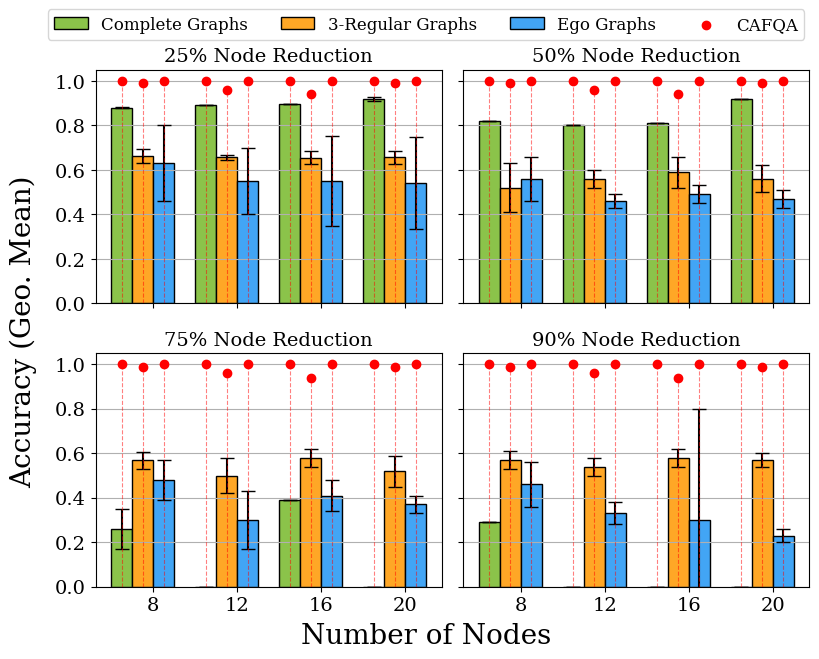

In [32]:


# Unweighted Red-QAOA comparision
# Placeholder values for Geometric Mean Red-QAOA Accuracy with AND=0.75, 0.5, 0.25, and 0.10
df_ego_unweighted_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],  # Placeholder values
    "Std CAFQA Accuracy": [0.04, 0.05, 0.06, 0.07],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.75)": [0.63, 0.55, 0.55, 0.54],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.75)": [0.17, 0.15, 0.203, 0.207],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.5)": [0.56,.46,0.49,0.47],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.5)": [0.1,0.03,0.04,0.04],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.25)": [0.48,0.3,0.41,0.37],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.25)": [0.09,0.13,0.07,0.04],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.10)": [0.46,0.33,0.3,0.23],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.10)": [0.1,0.05,0.5,0.03],  # Placeholder standard deviations
})

df_kreg_unweighted_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [0.99, 0.96, 0.94, 0.99],  # Placeholder values
    "Std CAFQA Accuracy": [0.02, 0.05, 0.03, 0.04],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.75)": [0.662, 0.656, 0.655, 0.656],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.75)": [0.03, 0.01, 0.03, 0.03],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.5)": [0.52,0.56,0.59,0.56],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.5)": [0.11,0.04,0.07,0.06],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.25)": [0.568,0.5,0.58,0.52],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.25)": [0.04,0.08,0.04,0.07],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.10)": [0.57,0.54,0.58,0.57],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.10)": [0.04,0.04,0.04,0.03],  # Placeholder standard deviations
})

df_complete_unweighted_graphs = pd.DataFrame({
    "Number of Qubits": [8, 12, 16, 20],
    "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],  # Placeholder values
    "Std CAFQA Accuracy": [0.0012,1e-16,4*1e-16,0.01],  # TODO: change
    "Geometric Mean Red-QAOA Accuracy (AND=0.75)": [0.88, 0.892, 0.898, 0.919],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.75)": [0.001, 1.1e-16, 4.21e-16, 0.01],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.5)": [0.82,0.80,0.81,0.92],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.5)": [0.0008,1e-16,1e-16,1e-16],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.25)": [0.26,1e-6,0.39,1e-6],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.25)": [0.09,1e-22,1e-16,1e-16],  # Placeholder standard deviations
    "Geometric Mean Red-QAOA Accuracy (AND=0.10)": [0.29,1e-6,1e-6,1e-6],  # Placeholder values
    "Std Red-QAOA Accuracy (AND=0.10)": [1e-6,1e-6,1e-21,1e-6],  # Placeholder standard deviations
})

# Create placeholder DataFrames for Ego Graphs and K-Regular Graphs accuracies
# df_ego_unweighted_graphs = pd.DataFrame({
#     "Number of Qubits": [8, 12, 16, 20],
#     "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],  # Placeholder values #NOTE: can be increased 
#     "Std CAFQA Accuracy": [0.04, 0.05, 0.06, 0.07],  # Placeholder standard deviations
#     "Geometric Mean Red-QAOA Accuracy": [0.63, 0.55, 0.55, 0.54],  # Placeholder values
#     "Std Red-QAOA Accuracy": [0.17, 0.15, 0.203, 0.207]  # Placeholder standard deviations
# })

# df_kreg_unweighted_graphs = pd.DataFrame({
#     "Number of Qubits": [8, 12, 16, 20],
#     "Geometric Mean CAFQA Accuracy": [0.99, 0.96, 0.94, 0.99],  # Placeholder values
#     "Std CAFQA Accuracy": [0.02, 0.05, 0.03, 0.04],  # Placeholder standard deviations
#     "Geometric Mean Red-QAOA Accuracy": [0.662, 0.656, 0.655, 0.656],  # Placeholder values
#     "Std Red-QAOA Accuracy": [0.03, 0.01, 0.03, 0.03]  # Placeholder standard deviations
# })

# # Create DataFrame for Complete Graphs accuracies
# df_complete_unweighted_graphs = pd.DataFrame({
#     "Number of Qubits": [8, 12, 16, 20],
#     "Geometric Mean CAFQA Accuracy": [1.0, 1.0, 1.0, 1.0],
#     "Std CAFQA Accuracy": [0, 0, 0, 0],  # Placeholder standard deviations
#     "Geometric Mean Red-QAOA Accuracy": [0.88, 0.892, 0.898, 0.919],  # Placeholder values #NOTE: todo
#     "Std Red-QAOA Accuracy": [0.001, 1.1e-16, 4.21e-16, 0.01]  # Placeholder standard deviations 
# })


# Grouped bar plot for geometric mean CAFQA accuracy for K-Regular and Ego Graphs
x = np.arange(len(df_kreg_accuracy["Number of Qubits"]))  # group positions
bar_width = 0.25

# fig, ax = plt.subplots(figsize=(8, 6))
# Create 4 subplots for each AND ratio|
fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
for ax in axs.flat:
    
    ax.set_ylim(0, 1.05)
    # Add scatter plot above each bar
    scatter_x = np.concatenate([
        x - bar_width * 1.5,  # x-coordinates for Complete Graphs
        x - bar_width / 2,    # x-coordinates for 3-Regular Graphs
        x + bar_width / 2     # x-coordinates for Ego Graphs
    ])
    scatter_y = np.concatenate([
        df_complete_unweighted_graphs["Geometric Mean CAFQA Accuracy"],  # y-coordinates for Complete Graphs
        df_kreg_unweighted_graphs["Geometric Mean CAFQA Accuracy"],    # y-coordinates for 3-Regular Graphs
        df_ego_unweighted_graphs["Geometric Mean CAFQA Accuracy"]        # y-coordinates for Ego Graphs
    ])
    ax.scatter(scatter_x, scatter_y, color="red", label="CAFQA", zorder=5)
    
    # Connect scatter points to respective bars with red dashed lines
    for i in range(len(scatter_x)):
        ax.plot(
            [scatter_x[i], scatter_x[i]],  # x-coordinates for the line
            [0, scatter_y[i]],             # y-coordinates for the line
            color="red",
            linestyle="dashed",
            linewidth=0.8,
            zorder=4,
            alpha=0.5,
            label="connections"
        )

    
and_ratios = ['0.75', '0.5', '0.25', '0.10']
colors = ["#8BC34A", "#FFA726", "#42A5F5"]
titles = [f"{int((1-float(ratio))*100)}% Node Reduction" for ratio in and_ratios]

for i, ax in enumerate(axs.flat):
    ratio = and_ratios[i]
    ax.bar(
        x - bar_width * 1.5,
        df_complete_unweighted_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={ratio})"],
        bar_width,
        yerr=df_complete_unweighted_graphs[f"Std Red-QAOA Accuracy (AND={ratio})"],
        label="Complete Graphs",
        color=colors[0],
        capsize=5,
        edgecolor="black",
    )
    ax.bar(
        x - bar_width / 2,
        df_kreg_unweighted_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={ratio})"],
        bar_width,
        yerr=df_kreg_unweighted_graphs[f"Std Red-QAOA Accuracy (AND={ratio})"],
        label="3-Regular Graphs",
        color=colors[1],
        capsize=5,
        edgecolor="black",
    )
    ax.bar(
        x + bar_width / 2,
        df_ego_unweighted_graphs[f"Geometric Mean Red-QAOA Accuracy (AND={ratio})"],
        bar_width,
        yerr=df_ego_unweighted_graphs[f"Std Red-QAOA Accuracy (AND={ratio})"],
        label="Ego Graphs",
        color=colors[2],
        capsize=5,
        edgecolor="black",
    )
    ax.set_title(titles[i], fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df_kreg_unweighted_graphs["Number of Qubits"], fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y")

# Add common labels and legend
fig.text(0.5, -0.02, "Number of Nodes", ha="center", fontsize=20)
fig.text(-0.02, 0.5, "Accuracy (Geo. Mean)", va="center", rotation="vertical", fontsize=20)
handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles[-3:]+[handles[0]],  # Select only the first three handles (Complete, 3-Regular, Ego)
    labels[-3:]+[labels[0]],   # Select only the first three labels
    loc="upper center",
    fontsize=12,
    ncol=4,
    bbox_to_anchor=(0.5, 1.05),
    frameon=True,
)
plt.tight_layout()
fig.savefig("../plots/Cafqa_accuracy_red_qaoa_unweighted_maxcut_comparision.pdf", dpi=800, bbox_inches='tight')
plt.show()